## This notebook improves the PINN performance from the previous example by adding a transform to the outputs of the neural network to directly embed constraints

#### Importing relevant libraries

In [1]:
import torch                       # ML library
import numpy as np                 # numpy for arrays
import tqdm                        # progress bar
import pytorch_optimizer           # optimizer library
import matplotlib.pyplot as plt    # plotting library

#### Choose hardware, RNG seed, and precision

In [2]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')  # Computer hardware
torch.manual_seed(1234)                                                              # PyTorch RNG seed
np.random.seed(1234)                                                                 # Numpy RNG seed
torch.set_default_dtype(torch.float64)                                               # Setting precision

#### Build a fully connected neural network, but add a transform of the form $ P = \tanh(\bar{p}P_{NN}^2)$, where $P_{NN}$ is the output of the network, and $\bar{p}$ is the normalized momentum variable. Here, we are automatically enforcing (1) the low boundary, (2) $P \in [0,1]$ to satisfy a probability value 

In [3]:
class FCNN(torch.nn.Module):
    def __init__(self, in_dim: int, width: int, out_dim: int):
        super().__init__()
        self.act       = torch.nn.Tanh()
        self.input     = torch.nn.Linear(in_dim, width)
        self.layer1    = torch.nn.Linear(width, width)
        self.layer2    = torch.nn.Linear(width, width)
        self.layer3    = torch.nn.Linear(width, width) 
        self.output    = torch.nn.Linear(width, out_dim)
        self._init_weights()

    def _init_weights(self):
        for m in [self.input,self.layer1,self.layer2,
                self.layer3,self.output]:
            torch.nn.init.xavier_normal_(m.weight)
            if m.bias is not None:
                torch.nn.init.zeros_(m.bias)

    def forward(self, x):
        p_bar = x[:,0:1]
        x = self.act(self.input(x))
        x = self.act(self.layer1(x))
        x = self.act(self.layer2(x))
        x = self.act(self.layer3(x))
        x = self.output(x)
        return torch.tanh(p_bar * x**2)

#### Construct the loss terms for the PDE and boundary condition(s)

In [4]:
'''
    PDE loss term
'''
def pde(model, X):
    # Build computational graph for backpropogation
    X = X.clone().requires_grad_(True)

    # Predict dependent variable
    P = model(X)

    # Compute derivatives w.r.t. normalized independent variables
    dP_dX = torch.autograd.grad(P, X, grad_outputs=torch.ones_like(P),create_graph=True)[0]
    dP_dpbar  = dP_dX[:, 0:1]
    dP_dxibar = dP_dX[:, 1:2]
    d2P_dxibar2 = torch.autograd.grad(dP_dxibar, X, grad_outputs=torch.ones_like(dP_dxibar),create_graph=True)[0][:, 1:2]

    # Convert to physical derivatives
    dP_dp    = dP_dpbar    /(pMax - pMin)
    dP_dxi   = dP_dxibar   /(xiMax - xiMin)
    d2P_dxi2 = d2P_dxibar2 /(xiMax - xiMin)
    
    # Physical independent variables
    pNorm, xiNorm = X[:, 0:1], X[:, 1:2]
    p  = pNorm  * (pMax  - pMin)  + pMin
    xi = xiNorm * (xiMax - xiMin) + xiMin

    # Compute derived variables
    g  = torch.sqrt(1.0 + p**2)
    C_F = g**2/p**2
    C_B = g/p * (Zeff + 1)

    # Compute PDE
    Estar = Ephi*(xi*dP_dp + ((1.0 - xi**2)/p)*dP_dxi)
    Cstar = C_F*dP_dp - C_B/2.0/(p**2)*((1.0 - xi**2)*d2P_dxi2 - 2.0*xi*dP_dxi)

    residual = Estar + Cstar
    return residual

'''
    Boundary loss term
'''
def BC(model, X):
    # Predict dependent variable
    P = model(X)
    
    # Physical independent variables
    pNorm, xiNorm = X[:, 0:1], X[:, 1:2]
    p  = pNorm  * (pMax  - pMin)  + pMin
    xi = xiNorm * (xiMax - xiMin) + xiMin
    
    # Compute derived variables
    g     = torch.sqrt(1.0 + p**2)
    CF    = g**2/p**2
    U_p   = -Ephi * xi - CF

    # Build conditionals with the appropriate boundary conditions
    cond_max = torch.where((U_p > 0) & torch.isclose(pNorm,torch.ones_like(pNorm)), 1.0, 0.0)
    cond_min = torch.isclose(pNorm,torch.zeros_like(pNorm))

    # P = 0 if p=p_min, P = 1 if p=p_max
    return torch.where(cond_min, P - 0.0, cond_max*(P - 1.0))


#### Define plasma parameters, domain, and collocation points

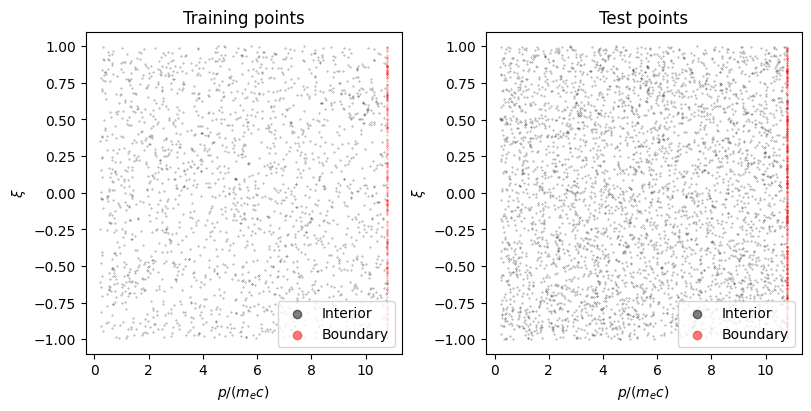

In [8]:
'''
    Function to sample points at p_min and p_max
'''
def generate_edge_points(num_points, x_min, x_max, y_min, y_max):
    # 0:bottom, 1:top, 2:left, 3:right
    edge = torch.randint(3, 4, (num_points,))
    
    # Randomly sample along the axis
    r = torch.rand(num_points)
    x_range = x_max - x_min
    y_range = y_max - y_min
    
    # Initialize points
    points = torch.zeros((num_points, 2))
    
    # Apply coordinates based on chosen edge
    points[:, 0] = torch.where(edge < 2, x_min + r * x_range, # Bottom/Top
                               torch.where(edge == 2, x_min, x_max)) # Left/Right
    points[:, 1] = torch.where(edge >= 2, y_min + r * y_range, # Left/Right
                               torch.where(edge == 0, y_min, y_max)) # Bottom/Top
    
    return points

# Define plasma parmaeters
Ephi = 1.5    # E_|| / E_C
Zeff = 1.0    # Effective charge

# Bounds of computional domain
pMin , pMax  =  0.2, 10.8   # p / (m_e*c)
xiMin, xiMax = -1.0,  1.0   # pitch-angle

# Generate training points
Ntrain_pde = 2**11
Ntrain_bc  = 2**8
Xpde = torch.rand(Ntrain_pde,2,device=device)
Xbc  = generate_edge_points(Ntrain_bc, x_min=0, x_max=1, y_min=0, y_max=1)

# Generate test points
Ntest_pde = 2**12
Ntest_bc  = 2**9
Xpde_test = torch.rand(Ntest_pde,2,device=device)
Xbc_test  = generate_edge_points(Ntest_bc, x_min=0, x_max=1, y_min=0, y_max=1)

# Plot training and test points
fig, ax = plt.subplots(ncols=2,constrained_layout=True,figsize=(8,4))

ax[0].scatter(Xpde[:,0]*(pMax-pMin)+pMin, Xpde[:,1]*(xiMax-xiMin)+xiMin, c='black',s=0.1,alpha=0.5)
ax[0].scatter(Xbc[:,0]*(pMax-pMin)+pMin, Xbc[:,1]*(xiMax-xiMin)+xiMin, c='red',s=0.1,alpha=0.5)
ax[1].scatter(Xpde_test[:,0]*(pMax-pMin)+pMin, Xpde_test[:,1]*(xiMax-xiMin)+xiMin, c='black',s=0.1,alpha=0.5)
ax[1].scatter(Xbc_test[:,0]*(pMax-pMin)+pMin, Xbc_test[:,1]*(xiMax-xiMin)+xiMin, c='red',s=0.1,alpha=0.5)

ax[0].scatter([],[],c='black',alpha=0.5,label='Interior')
ax[0].scatter([],[],c='red',alpha=0.5,label='Boundary')
ax[1].scatter([],[],c='black',alpha=0.5,label='Interior')
ax[1].scatter([],[],c='red',alpha=0.5,label='Boundary')

ax[0].set_title('Training points')
ax[1].set_title('Test points')

ax[0].legend(loc='lower right')
ax[1].legend(loc='lower right')

ax[0].set_ylabel(r'$\xi$')
ax[1].set_ylabel(r'$\xi$')

ax[0].set_xlabel(r'$p/(m_ec)$')
ax[1].set_xlabel(r'$p/(m_ec)$')

plt.show()

#### Define neural network and training parameters, and train the PINN

In [ ]:
# Initialize neural network, optimization
# and prescribe a learning rate decay
model = FCNN(in_dim=2, width=32, out_dim=1).to(device)
optimizer = pytorch_optimizer.optimizer.soap.SOAP(
    model.parameters(),lr=1e-3, betas=(.997, .997),
    weight_decay=0.0,precondition_frequency=1
)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99995)

# Define number of training iterations
Nepochs        = 15000
pbar = tqdm.trange(Nepochs, ncols=128)

# Initialize lists to store training and test loss
pde_loss_hist     , bc_loss_hist       = [], []
pde_test_loss_hist, bc_test_loss_hist  = [], []

# Main training loop
for i in pbar:
    model.train()
    optimizer.zero_grad()

    lp   = torch.mean(pde(model, Xpde)**2)
    lb   = torch.mean(BC(model, Xbc)**2)

    loss = lp +lb
    loss.backward()
    optimizer.step()
    scheduler.step()

    pde_loss_hist.append(lp.detach().cpu().numpy())
    bc_loss_hist.append(lb.detach().cpu().numpy())

    model.eval()
    lp_t = torch.mean(pde(model, Xpde_test)**2)
    with torch.no_grad():
        lb_t = torch.mean(BC(model, Xbc_test)**2)

    pde_test_loss_hist.append(lp_t.detach().cpu().numpy())
    bc_test_loss_hist.append(lb_t.cpu().numpy())

    pbar.set_postfix({
        "L_PDE": f"{lp.item():.3e}"  ,"L_BC": f"{lb.item():.3e}",
        "T_PDE": f"{lp_t.item():.3e}","T_BC": f"{lb_t.item():.3e}",
    })

# plot loss history
fig, ax = plt.subplots(constrained_layout=True)
ax.set_xlabel("Epochs [thousands]")
ax.set_title("Loss History")
ax.set_yscale("log")

epochs = np.arange(len(pde_loss_hist))/1e3

ax.plot(epochs,pde_loss_hist,label="PDE",c='blue')
ax.plot(epochs,bc_loss_hist,label="BC",c='darkorange')
ax.plot(epochs, pde_test_loss_hist, marker='x',c='blue',ls='none', markevery=100)
ax.plot(epochs, bc_test_loss_hist, marker='x',c='darkorange',ls='none', markevery=100)
ax.plot([],[],ls='-',label='train',c='black')
ax.plot([],[],ls='none',marker='x',label='test',color='black')
ax.legend(fontsize=14,ncol=2)
plt.show()

 33%|██████▌             | 4880/15000 [01:53<03:53, 43.40it/s, L_PDE=6.917e-08, L_BC=5.870e-09, T_PDE=6.693e-05, T_BC=9.027e-09]

#### Plot the learned solution, and the corresponding PDE residual error

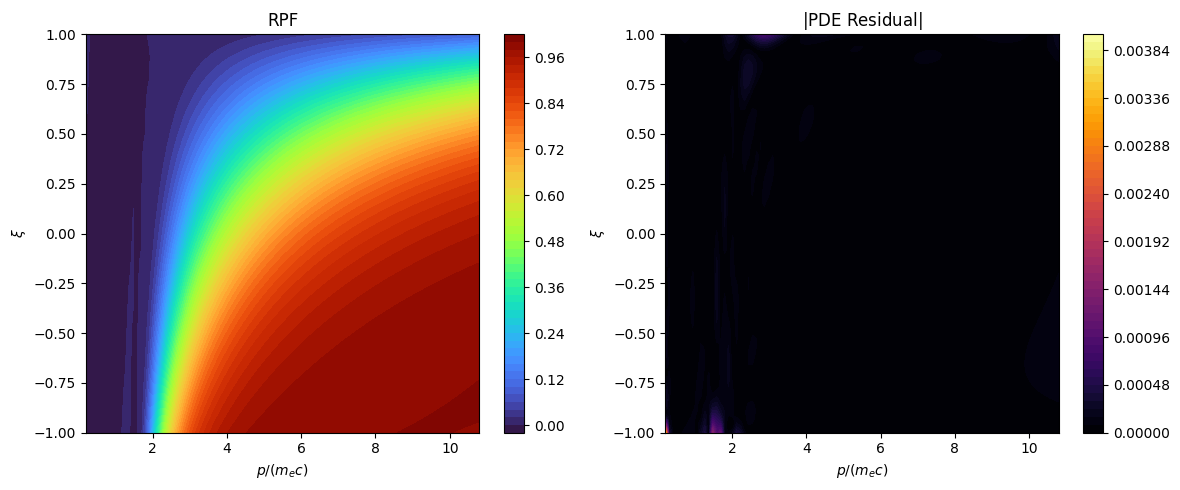

In [205]:
num_p, num_xi = 100, 99
pGrid      = np.linspace(pMin,  pMax,  num_p)
xiGrid     = np.linspace(xiMin, xiMax, num_xi)

pNorm  = (pGrid-pMin)/(pMax-pMin)
xiNorm = (xiGrid-xiMin)/(xiMax-xiMin)

pMesh_norm, xiMesh_norm = np.meshgrid(pNorm, xiNorm, indexing='ij')
pMesh  = pMesh_norm  * (pMax  - pMin)  + pMin
xiMesh = xiMesh_norm * (xiMax - xiMin) + xiMin

fig, ax = plt.subplots(ncols=2,constrained_layout=True,figsize=(12,5))
fig.set_tight_layout(True)

Xpred = torch.cat([
    torch.tensor(pMesh_norm).to(device).reshape(-1,1),
    torch.tensor(xiMesh_norm).to(device).reshape(-1,1),
],dim=1)
    
model.eval()
with torch.no_grad():
    P = model(Xpred).detach().reshape(pMesh.shape).cpu().numpy()
pde_res = pde(model, Xpred).detach().reshape(pMesh.shape).cpu().numpy()

cp0 = ax[0].contourf(pMesh,xiMesh,P,levels=50,cmap='turbo')
cp1 = ax[1].contourf(pMesh,xiMesh,abs(pde_res),levels=50,cmap='inferno')

fig.colorbar(cp0,ax=ax[0])
fig.colorbar(cp1,ax=ax[1])

ax[1].set_xlabel(r'$p/(m_ec)$')
ax[0].set_xlabel(r'$p/(m_ec)$')
ax[1].set_ylabel(r'$\xi$')
ax[0].set_ylabel(r'$\xi$')
ax[0].set_title('RPF')
ax[1].set_title('$|$PDE Residual$|$')

plt.show()